In [19]:
# Imports
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from hysys import open_case, cache_objects, run_point, dump, members
import hysys

In [2]:
# Setup
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\methanol.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case not open in HYSYS - launching (this can take a minute)...
Case name:        Case
Material streams: 42
Connected in      27.3 s
Objects cached OK:
  solver
  units
  co2in
  h2in
  rin
  rout
  methanol
  purge
  recycle_gas
  reactor
  split
  column
  flare
  recycle
  pressure_cell
  ratio_cell
  h2_index
  co2_index
  meoh_index


In [77]:
PRESSURE = 90 # bar
RATIO = 3.0 # H2 to CO2
VOLUME = 19 # m3

def T_purge_sweep():
    results = []
    all_temp = np.linspace(220, 280, 20) # [C]
    all_purge = np.linspace(0.01, 0.05, 5) # [-]

    for T, prg in itertools.product(all_temp, all_purge):
        print("procesing", "T", T, "Purge", prg)
        point = dict(temperature=(T, "C"), purge_rate=(prg), pressure=(PRESSURE, "bar"), ratio=(RATIO), volume=(VOLUME, "m3"))
        try:
            results.append(run_point(objects, **point))
        except Exception as e:
            results.append(dict(temperature_set=T, purge_rate_set=prg, converged=False, error=str(e)))

    return results
results = T_purge_sweep()

procesing T 220.0 Purge 0.01
procesing T 220.0 Purge 0.02
procesing T 220.0 Purge 0.03
procesing T 220.0 Purge 0.04
procesing T 220.0 Purge 0.05
procesing T 223.1578947368421 Purge 0.01
procesing T 223.1578947368421 Purge 0.02
procesing T 223.1578947368421 Purge 0.03
procesing T 223.1578947368421 Purge 0.04
procesing T 223.1578947368421 Purge 0.05
procesing T 226.31578947368422 Purge 0.01
procesing T 226.31578947368422 Purge 0.02
procesing T 226.31578947368422 Purge 0.03
procesing T 226.31578947368422 Purge 0.04
procesing T 226.31578947368422 Purge 0.05
procesing T 229.4736842105263 Purge 0.01
procesing T 229.4736842105263 Purge 0.02
procesing T 229.4736842105263 Purge 0.03
procesing T 229.4736842105263 Purge 0.04
procesing T 229.4736842105263 Purge 0.05
procesing T 232.6315789473684 Purge 0.01
procesing T 232.6315789473684 Purge 0.02
procesing T 232.6315789473684 Purge 0.03
procesing T 232.6315789473684 Purge 0.04
procesing T 232.6315789473684 Purge 0.05
procesing T 235.78947368421052

In [105]:
df = pd.DataFrame(results)
df.columns
if not df["converged"].all():
    print("Warning: Not all points converged")

In [84]:
def heatmap(df, value, label, *, x="purge_rate_set", y="temperature_set", levels=6, cmap="viridis", ax=None, title=None):
    """Heatmap of value over (x, y); non-converged cells in grey."""
    _df = df.copy()
    _df["value_plot"] = _df[value].where(_df["converged"])
    grid = _df.pivot(index=y, columns=x, values="value_plot")
    if ax is None:
        _, ax = plt.subplots(1, 1) 
    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("0.85")
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap=cmap, shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=levels, colors="black", linewidths=1)
    ax.clabel(cs, fmt="%.0f")
    ax.set_xlabel("purge-rate [-]")
    ax.set_ylabel("T [$^\\circ{C}$]")
    ax.set_title(title)
    ax.figure.colorbar(mesh, ax=ax, label=label)

    return ax

<Axes: title={'center': 'Methanol Production'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

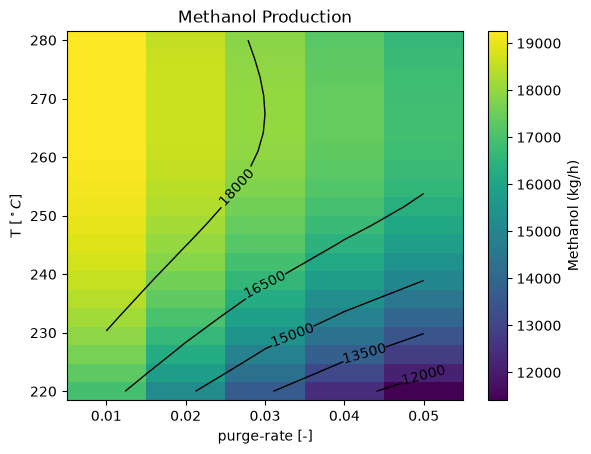

In [106]:
df = pd.DataFrame(results)
heatmap(df, "methanol_kg_h", "Methanol (kg/h)", title="Methanol Production")

<Axes: title={'center': 'Recycle Ratio'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

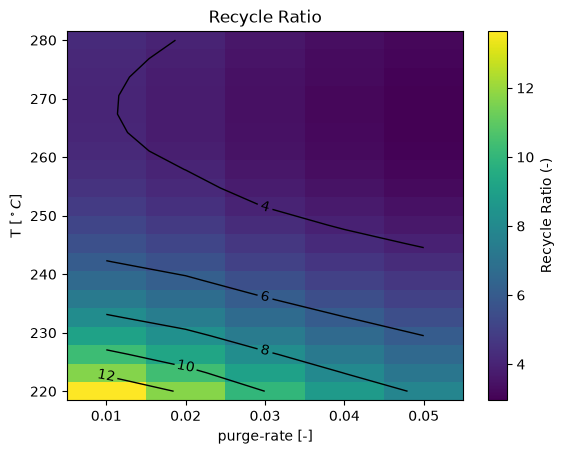

In [107]:
heatmap(df, "recycle_ratio", "Recycle Ratio (-)", title="Recycle Ratio")

<Axes: title={'center': 'Pressure Drop'}, xlabel='purge-rate [-]', ylabel='T [$^\\circ{C}$]'>

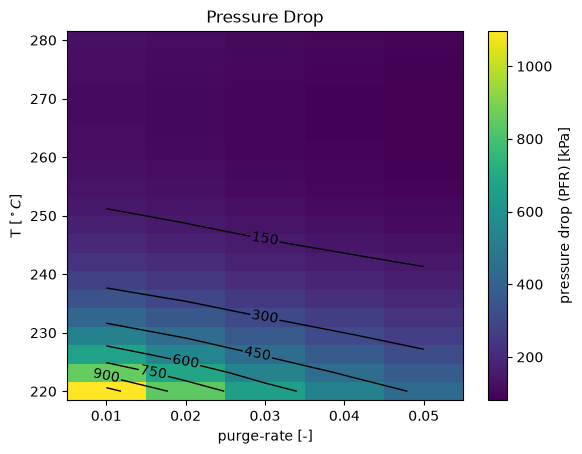

In [108]:
heatmap(df, "reactor_dP_kPa", "pressure drop (PFR) [kPa]", title="Pressure Drop")